# Objectif du notebook 

Date de création : 24/02/2026

Analyse du Doppler différentiel dans le réseau de capteurs  

In [2]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy

In [3]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

rtf_mfp_img_folder = os.path.join(img_folder, "rtf_mfp", "library_active_event_active")

In [4]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, LargeFigure, color 
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import (
    get_dists_2,
    get_dists,
    derive_doppler
)
from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    FiberscopeManager,
    BandFilter,
)

# Chargement des données 

In [5]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

# Source event à localiser : source tractée 

In [6]:
event_seq_id = 144
df_event = df_arr.loc[df_arr["sequence_id"] == event_seq_id]

root_fig = os.path.join(rtf_mfp_img_folder, f"trailed_{event_seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

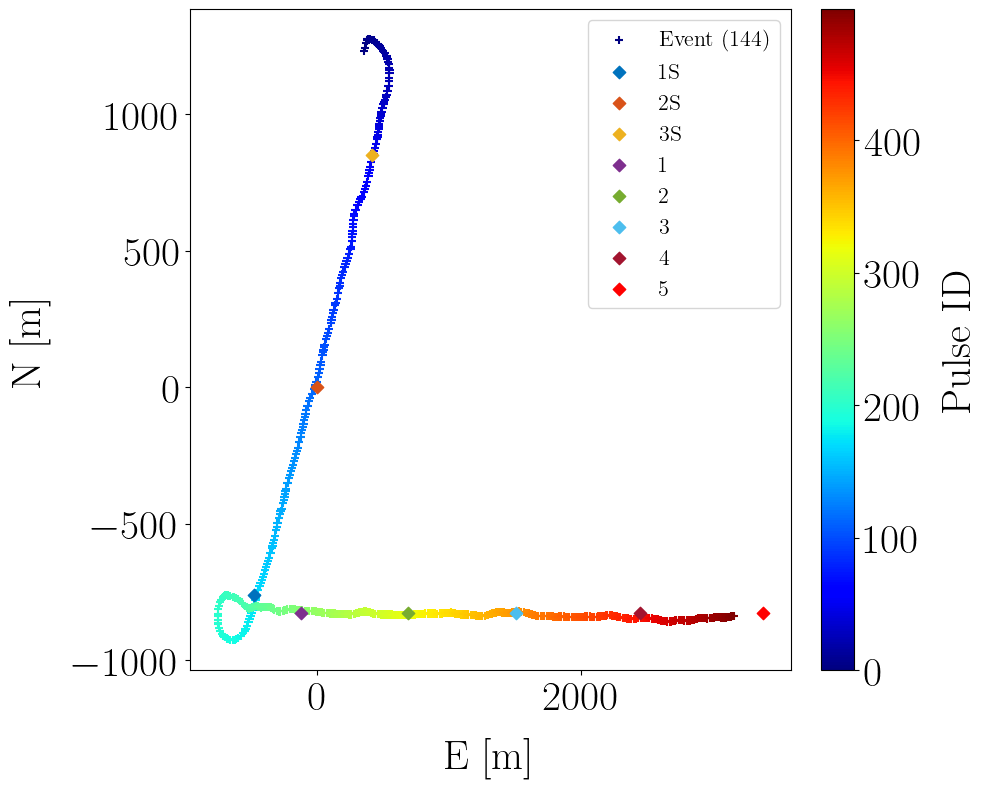

In [7]:
# Tracer des positions d'émission et des positions des OBS sur une carte
df_arr_plot = df_event

seq_mean_fscore = []

pfig = PubFigure(size=(10,8), legend_fontsize=16)
# Plot
plt.figure()
for i, seq_id in enumerate(df_arr_plot["sequence_id"].unique()):
    df_sequence = df_arr.loc[df_arr["sequence_id"] == seq_id]

    mean_f_score = (
        df_sequence["f_score_obs1"].iloc[0]
        + df_sequence["f_score_obs2"].iloc[0]
        + df_sequence["f_score_obs3"].iloc[0]
    ) / 3
    seq_mean_fscore.append(mean_f_score)

    # Série de positions successives
    plt.scatter(
        df_sequence["emission_interp_e_gps"],
        df_sequence["emission_interp_n_gps"],
        marker="+",
        label=f"Event ({seq_id})",
        c=np.arange(df_sequence["emission_interp_e_gps"].size),
        cmap="jet"
    )

    # # Add speed
    # plt.quiver(
    #     df_sequence["emission_interp_e_gps"],
    #     df_sequence["emission_interp_n_gps"],
    #     df_sequence["emission_interp_ve_gps"],
    #     df_sequence["emission_interp_vn_gps"],
    #     zorder=3,
    #     # "x",
    #     # label="GPS Fixed (interp)",
    #     # color="k",
    # )

plt.colorbar(label="Pulse ID")
plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
label = {
    "obs1": "1S",
    "obs2": "2S",
    "obs3": "3S",
    "t1": "1",
    "t2": "2",
    "t3": "3",
    "t4": "4",
    "t5": "5",
}
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=label[k],
        zorder=10,
        color=color(ik),
        s=40,
    )

plt.legend()

fpath = os.path.join(root_fig, "trailed_trajectory.png")
plt.savefig(fpath)

In [8]:
# Compute Doppler at central frequency for each receiver along the source
f0 = 210
x_src_rcv, v_src, v_src_to_rcv, v_src_to_rcv_norm, shifted_freq = derive_doppler(
    ds_gps=ds_gps, df_seq=df_event, f0=f0
)

(-1500.0, 1500.0)

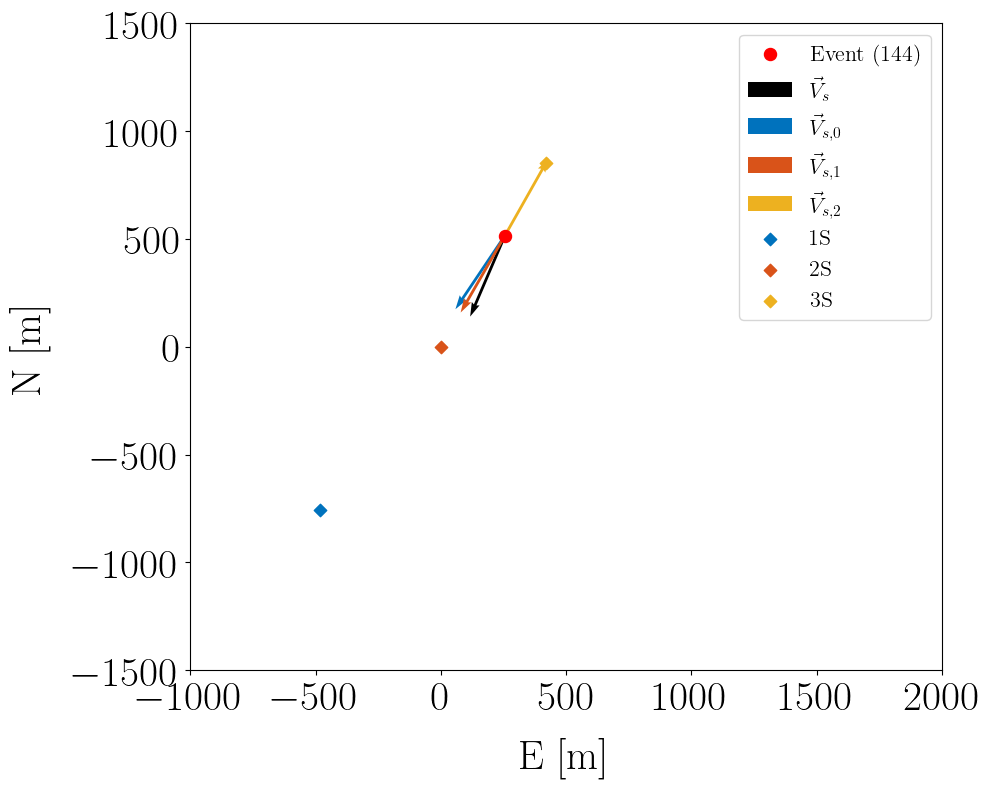

In [118]:
# Illustration calcul du Doppler
i_pulse = 75

pfig = PubFigure(size=(10, 8), legend_fontsize=16)
# Plot
plt.figure()
df_i_pulse = df_event.loc[df_event["pulse_id"] == i_pulse]


# Source position
plt.scatter(
    df_i_pulse["emission_interp_e_gps"],
    df_i_pulse["emission_interp_n_gps"],
    marker="o",
    s=75,
    color="r", 
    zorder=10,
    label=f"Event ({seq_id})",
)

# Add speed
plt.quiver(
    df_i_pulse["emission_interp_e_gps"],
    df_i_pulse["emission_interp_n_gps"],
    df_i_pulse["emission_interp_ve_gps"],
    df_i_pulse["emission_interp_vn_gps"],
    zorder=3,
    scale=0.005,
    scale_units="xy",
    angles="xy",
    units="xy",
    width=12,
    label=r"$\vec{V}_s$",
)

# plt.quiver(
#     0,
#     0,
#     df_i_pulse["emission_interp_e_gps"],
#     df_i_pulse["emission_interp_n_gps"],
#     zorder=3,
#     scale=1,
#     scale_units="xy",
#     angles="xy",
# )


# plt.quiver(
#     df_i_pulse["emission_interp_e_gps"],
#     df_i_pulse["emission_interp_n_gps"],
#     v_src[i_pulse, 0],
#     v_src[i_pulse, 1],
#     zorder=3,
#     scale=20,
#     color="r"
# )

for i_rcv in range(3):
    x_src_rcv_norm = np.linalg.norm(x_src_rcv[i_pulse, :, i_rcv])
    src_speed_norm = np.abs(v_src_to_rcv_norm[i_pulse, i_rcv])
    plt.quiver(
        df_i_pulse["emission_interp_e_gps"],
        df_i_pulse["emission_interp_n_gps"],
        x_src_rcv[i_pulse, 0, i_rcv] / x_src_rcv_norm * src_speed_norm,
        x_src_rcv[i_pulse, 1, i_rcv] / x_src_rcv_norm * src_speed_norm,
        zorder=3,
        color=color(i_rcv),
        scale=0.005,
        scale_units="xy",
        angles="xy",
        units="xy",
        width=12,
        # headwidth=1,
        # headlength=5,
        label=rf"$\vec{{V}}_{{s,{{{i_rcv}}}}}$",
    )


plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3"]
label = {
    "obs1": "1S",
    "obs2": "2S",
    "obs3": "3S",
    "t1": "1",
    "t2": "2",
    "t3": "3",
    "t4": "4",
    "t5": "5",
}
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=label[k],
        zorder=10,
        color=color(ik),
        s=40,
    )

plt.legend()

# fpath = os.path.join(root_fig, "trailed_trajectory.png")
# plt.savefig(fpath)
plt.xlim([-1000, 2000])
plt.ylim([-1500, 1500])

Text(0, 0.5, 'Radial speed [m/s]')

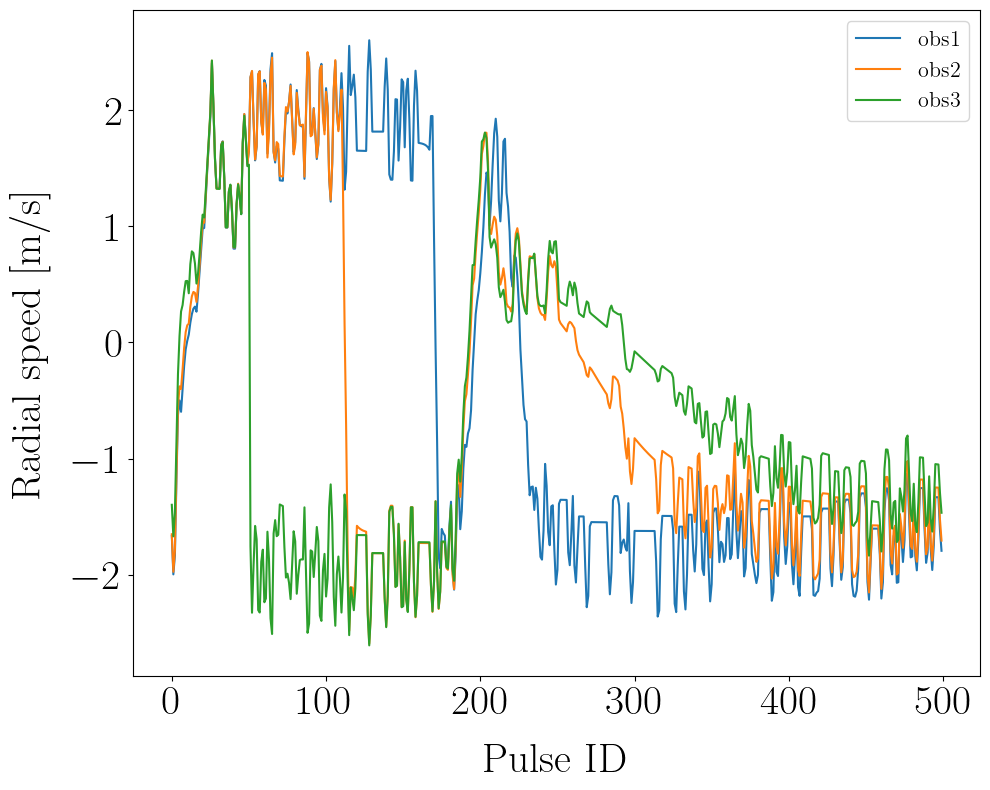

In [10]:
rcv = [f"obs{i}" for i in range(1, 4)]
plt.figure()
for i, rcv_i in enumerate(rcv):
    plt.plot(v_src_to_rcv_norm[:, i], label=rcv_i)

plt.legend() 
plt.xlabel("Pulse ID")
plt.ylabel("Radial speed [m/s]")

df_min = -0.3652538904263736 Hz df_max = 0.33011561994396743 Hz
df_range = 0.695369510370341 Hz
df_min = -0.3508945779414603 Hz df_max = 0.3625679428371029 Hz
df_range = 0.7134625207785632 Hz
df_min = -0.34077060101151346 Hz df_max = 0.36479470788009394 Hz
df_range = 0.7055653088916074 Hz


Text(0, 0.5, '$\\Delta f$ [Hz]')

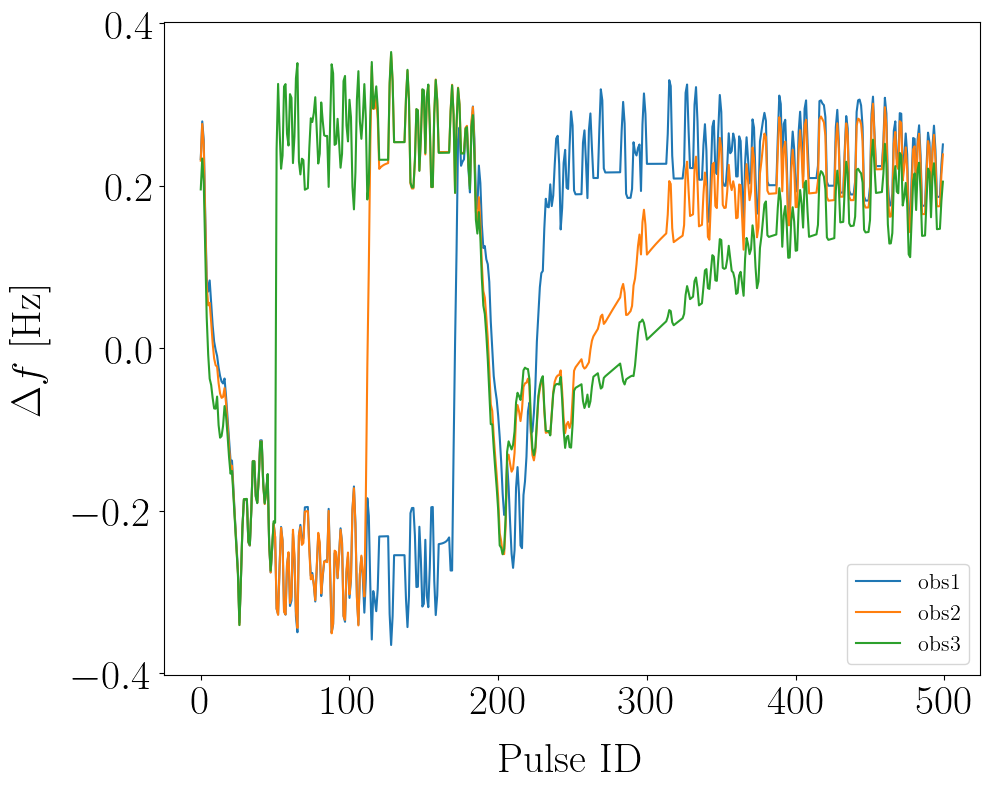

In [11]:
rcv = [f"obs{i}" for i in range(1, 4)]
plt.figure()
for i, rcv_i in enumerate(rcv):
    delta_f = f0 - shifted_freq[:, i]
    plt.plot(delta_f, label=rcv_i)
    print(f"df_min = {np.min(delta_f)} Hz", f"df_max = {np.max(delta_f)} Hz")
    print(f"df_range = {np.max(delta_f) - np.min(delta_f)} Hz")

plt.legend()
plt.xlabel("Pulse ID")
plt.ylabel(r"$\Delta f$ [Hz]")

Text(0, 0.5, '$\\Delta f$ [Hz]')

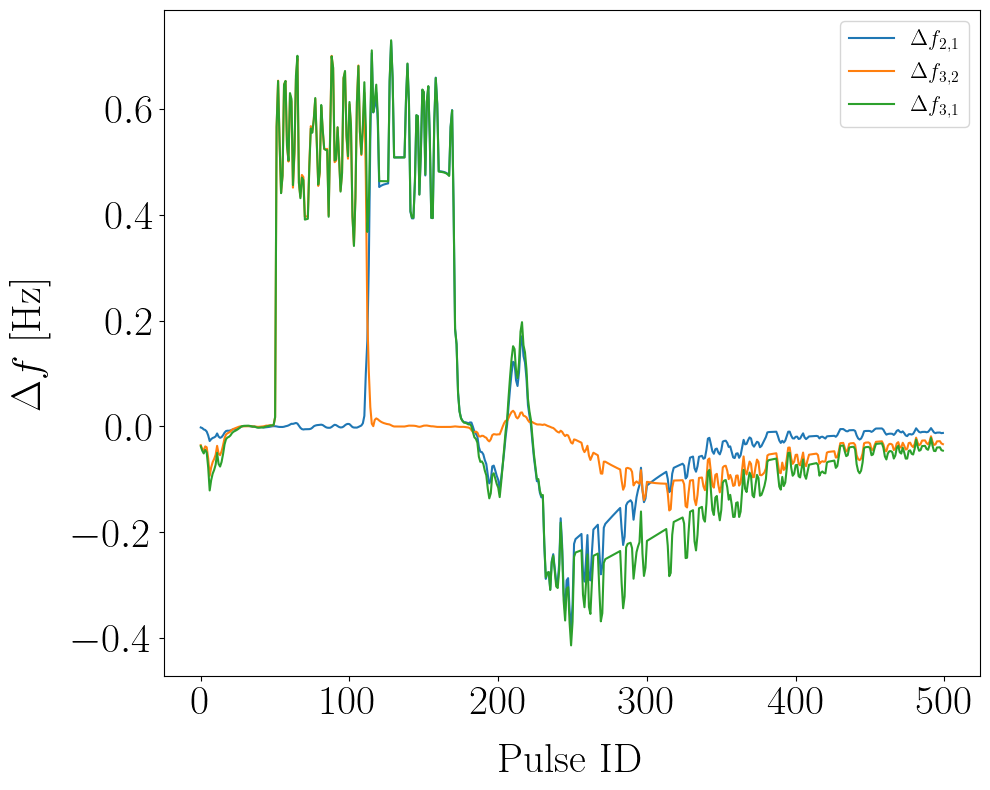

In [12]:
# Differential doppler
rcv = [f"obs{i}" for i in range(1, 4)]
plt.figure()

delta_i = f0 - shifted_freq[:, 0]
delta_j = f0 - shifted_freq[:, 1]
diff_doppler_ij = delta_j - delta_i
plt.plot(diff_doppler_ij, label=fr"$\Delta f_{{{2}, {1}}}$")
delta_i = f0 - shifted_freq[:, 1]
delta_j = f0 - shifted_freq[:, 2]
diff_doppler_ij = delta_j - delta_i
plt.plot(diff_doppler_ij, label=rf"$\Delta f_{{{3}, {2}}}$")
delta_i = f0 - shifted_freq[:, 0]
delta_j = f0 - shifted_freq[:, 2]
diff_doppler_ij = delta_j - delta_i
plt.plot(diff_doppler_ij, label=rf"$\Delta f_{{{3}, {1}}}$")

plt.legend()
plt.xlabel("Pulse ID")
plt.ylabel(r"$\Delta f$ [Hz]")

# Calcul du shift doppler sur une raie du navire 


In [13]:
# Chargement des données de la séquence étudiée

fpath = os.path.join(data_folder, "sequences", f"sequence_{event_seq_id}.nc")
ds_sig = xr.open_dataset(fpath)

In [14]:
ds_sig

<xarray.Dataset> Size: 515MB
Dimensions:                     (h_index: 3, time: 8018430, pulse_id: 498,
                                 t_ir: 10801, f_ir: 5401)
Coordinates:
  * h_index                     (h_index) int32 12B 1 2 3
  * time                        (time) float64 64MB 0.0 0.0005 ... 4.009e+03
  * pulse_id                    (pulse_id) int32 2kB 0 1 2 3 ... 496 497 498 499
  * t_ir                        (t_ir) float64 86kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float64 43kB 0.0 0.1852 ... 999.7 999.9
Data variables:
    signal                      (h_index, time) float64 192MB ...
    arr_time_in_sec_from_start  (h_index, pulse_id) float64 12kB ...
    ri_hat                      (h_index, t_ir, pulse_id) float64 129MB ...
    tf_hat_amp                  (h_index, f_ir, pulse_id) float64 65MB ...
    tf_hat_phase                (h_index, f_ir, pulse_id) float64 65MB ...
Attributes: (12/16)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        6.1754999999999995
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_10-51-05
    ...                        ...
    pulse_duration:            5.0
    inter_pulse_period:        8.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 c:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    fpath:                     c:\Users\baptiste.menetrier\Desktop\devPy\phd\...

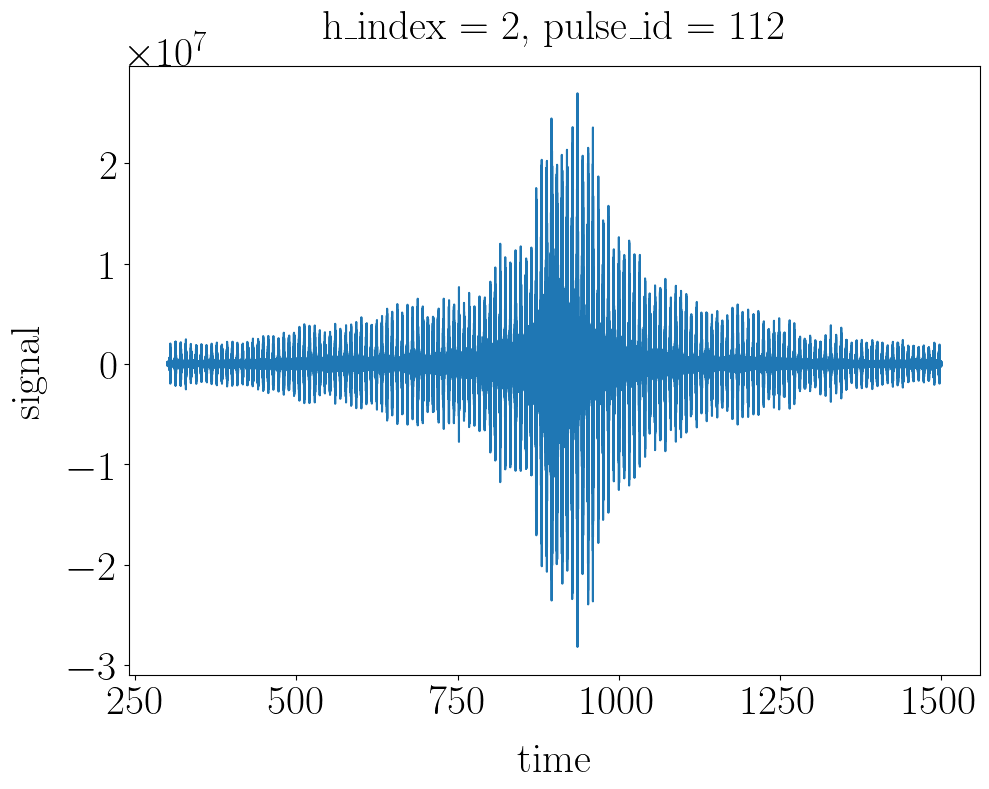

In [83]:
pulse_i = 112
sig_obs = ds_sig.sel(pulse_id=pulse_i, h_index=2)

tmin = 300
tmax = 1500
sig_obs = sig_obs.sel(time=slice(tmin, tmax))
sig_obs.signal.plot()

# plt.figure()
# plt.plot(sig_obs_1.signal.values)

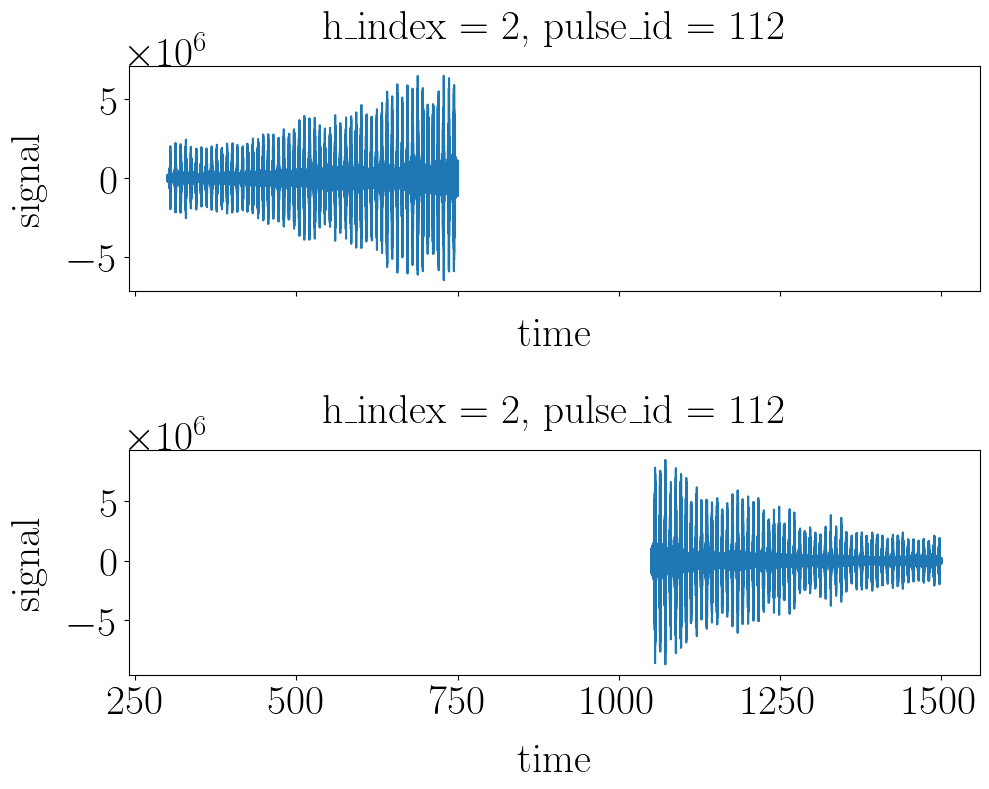

In [110]:
t_w = 450
n_w = t_w * ds_sig.fs
sig_obs_before_cpa = sig_obs.sel(time=slice(tmin, tmin + t_w))
sig_obs_after_cpa = sig_obs.sel(time=slice(tmax - t_w, tmax))

fig, axs = plt.subplots(2, 1, sharex=True)
sig_obs_before_cpa.signal.plot(ax=axs[0])
sig_obs_after_cpa.signal.plot(ax=axs[1])

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_18300\1684811160.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


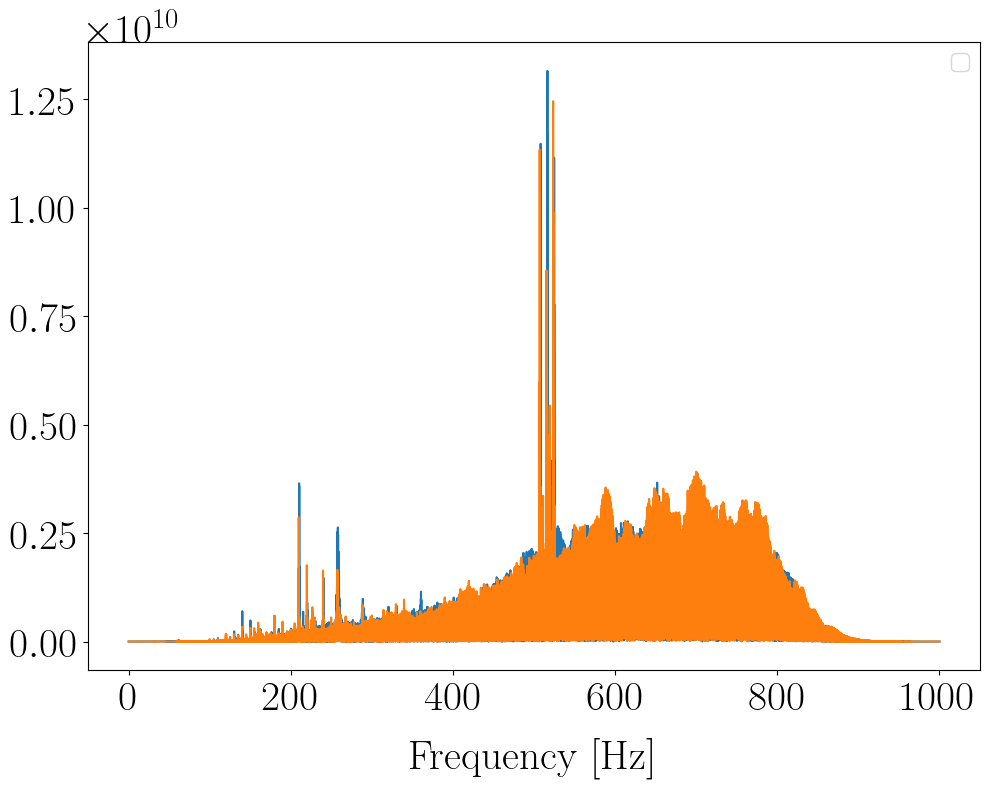

In [111]:
sig_obs_before_cpa_fft = scipy.fft.rfft(sig_obs_before_cpa.signal.values)
sig_obs_after_cpa_fft = scipy.fft.rfft(sig_obs_after_cpa.signal.values)
freq = scipy.fft.rfftfreq(n_w, d=1/ds_sig.fs)
# mag_before = np.abs(sig_obs_before_cpa_fft) / np.max(np.abs(sig_obs_before_cpa_fft))
# mag_after = np.abs(sig_obs_after_cpa_fft) / np.max(np.abs(sig_obs_after_cpa_fft))
mag_before = np.abs(sig_obs_before_cpa_fft) 
mag_after = np.abs(sig_obs_after_cpa_fft) 

plt.figure()
plt.plot(freq, mag_before)
plt.plot(freq, mag_after)
plt.xlabel("Frequency [Hz]")
# plt.xlim([0, 400])
plt.legend()

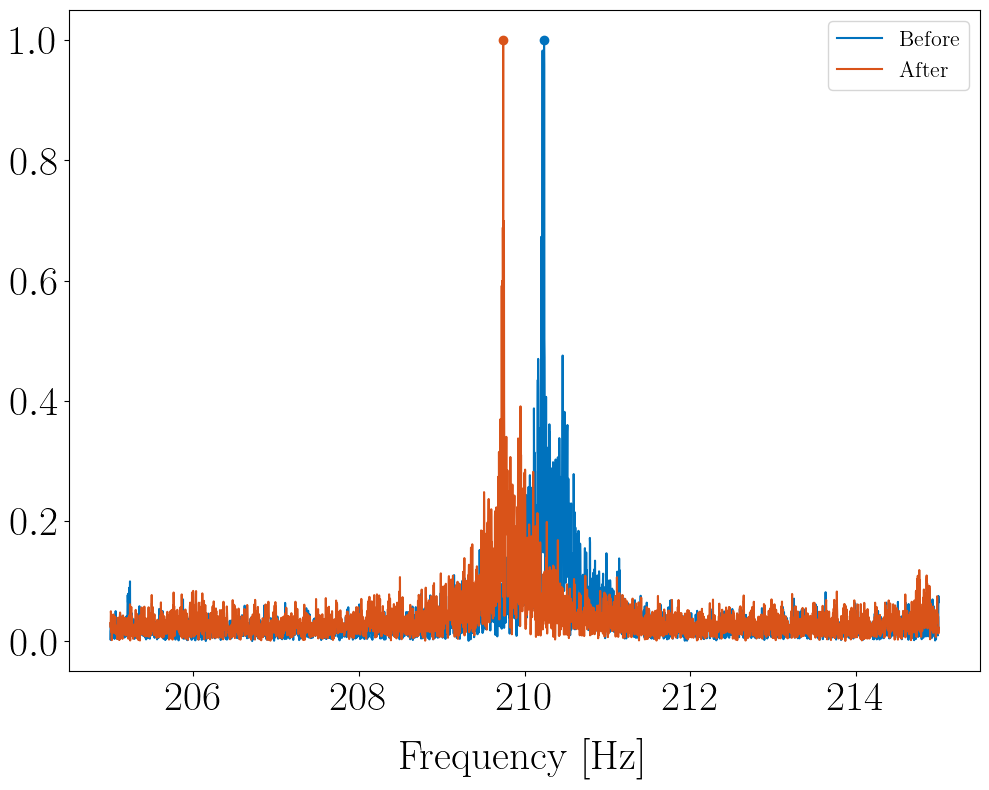

In [112]:
# Select frequency band

fmin = 205
fmax = 215

# fmin = 118
# fmax = 122

# fmin = 209
# fmax = 211

# fmin = 505
# fmax = 510
idx_freq_in_band = np.logical_and((freq >= fmin), (freq <= fmax))
freq_in_band = freq[idx_freq_in_band]
sig_obs_before_cpa_fft_in_band = sig_obs_before_cpa_fft[idx_freq_in_band]
sig_obs_after_cpa_fft_in_band = sig_obs_after_cpa_fft[idx_freq_in_band]
magnitude_norm_before = np.abs(sig_obs_before_cpa_fft_in_band) / np.max(np.abs(sig_obs_before_cpa_fft_in_band))
magnitude_norm_after = np.abs(sig_obs_after_cpa_fft_in_band) / np.max(np.abs(sig_obs_after_cpa_fft_in_band))
# max_amp = max(
#     np.max(np.abs(sig_obs_before_cpa_fft_in_band)),
#     np.max(np.abs(sig_obs_after_cpa_fft_in_band)),
# )
# magnitude_norm_before = np.abs(sig_obs_before_cpa_fft_in_band) / max_amp
# magnitude_norm_after = np.abs(sig_obs_after_cpa_fft_in_band) / max_amp


# Find peaks
df = ds_sig.fs / n_w
dist = (fmax - fmin) / df  # To ensure single peak detection
peaks_before, props_before = scipy.signal.find_peaks(magnitude_norm_before, distance=dist)
peaks_after, props_after = scipy.signal.find_peaks(
    magnitude_norm_after, distance=dist
)

plt.figure()
plt.plot(freq_in_band, magnitude_norm_before, label="Before", color=color(0))
plt.plot(freq_in_band, magnitude_norm_after, label="After", color=color(1))
# Add detected peaks
plt.scatter(
    freq_in_band[peaks_before], magnitude_norm_before[peaks_before], color=color(0)
)
plt.scatter(
    freq_in_band[peaks_after], magnitude_norm_after[peaks_after], color=color(1)
)

plt.xlabel("Frequency [Hz]")
plt.legend()
# plt.xlim([0, 400])

In [113]:
f_ray_before = freq_in_band[peaks_before]
f_ray_after = freq_in_band[peaks_after]
delta_f = f_ray_before - f_ray_after
print(f"Delta f = {delta_f} Hz")

Delta f = [0.49333333] Hz


In [114]:
# Select frequency ban
nperseg=2**15
noverlap=int(nperseg*0.75)

ff, Pxx_before = scipy.signal.welch(
    sig_obs_before_cpa.signal.values,
    fs=ds_sig.fs,
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)

ff, Pxx_after= scipy.signal.welch(
    sig_obs_after_cpa.signal.values,
    fs=ds_sig.fs,
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
)

idx_ff_in_band = np.logical_and((ff >= fmin), (ff <= fmax))
ff_in_band = ff[idx_ff_in_band]
Pxx_before_in_band = 10*np.log10(Pxx_before[idx_ff_in_band])
Pxx_after_in_band = 10*np.log10(Pxx_after[idx_ff_in_band])

# Peak detection
dff = ff[1] - ff[0]
dist_ff = (fmax - fmin) / dff  # To ensure single peak detection
peaks_before, props_before = scipy.signal.find_peaks(
    Pxx_before_in_band, distance=dist_ff
)
peaks_after, props_after = scipy.signal.find_peaks(Pxx_after_in_band, distance=dist_ff)

(205.0, 215.0)

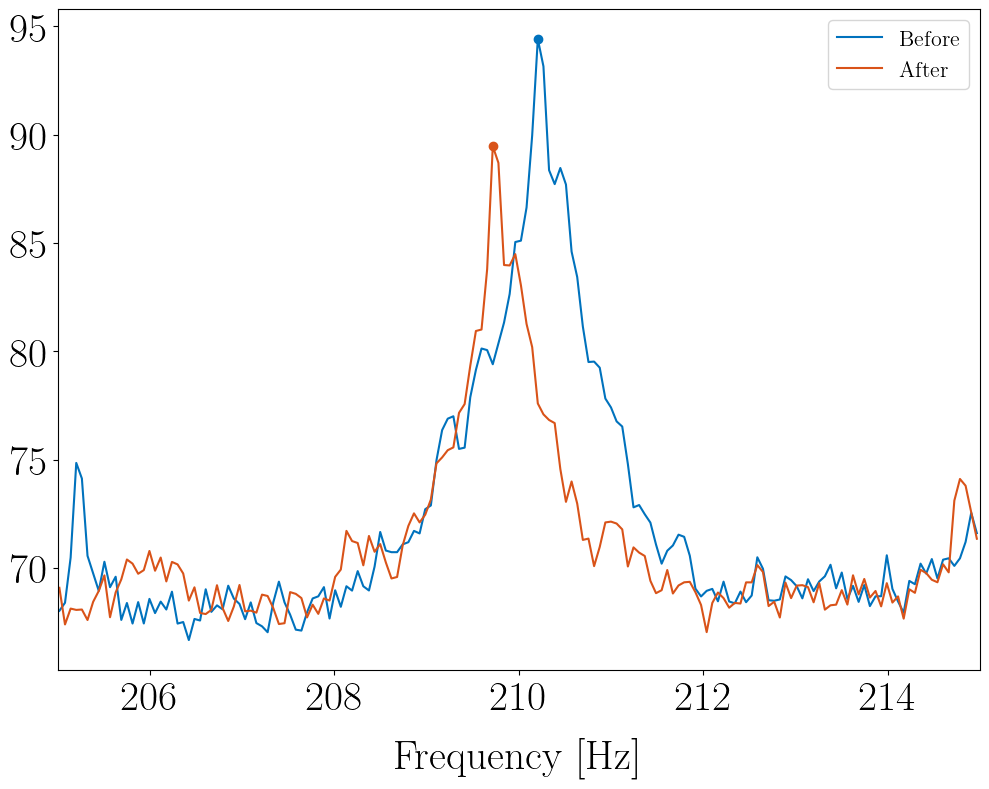

In [115]:
plt.figure()
plt.plot(ff_in_band, Pxx_before_in_band, label="Before", color=color(0))
plt.plot(ff_in_band, Pxx_after_in_band, label="After", color=color(1))
# # Add detected peaks
plt.scatter(ff_in_band[peaks_before], Pxx_before_in_band[peaks_before], color=color(0))
plt.scatter(ff_in_band[peaks_after], Pxx_after_in_band[peaks_after], color=color(1))

plt.xlabel("Frequency [Hz]")
plt.legend()
plt.xlim([205, 215])
# plt.ylim([80, 120])
# plt.xlim([500, 540])
# plt.ylim([80, 120])

In [116]:
f_ray_before = ff_in_band[peaks_before]
f_ray_after = ff_in_band[peaks_after]
delta_f = f_ray_before - f_ray_after
print(f"Delta f = {delta_f} Hz")

Delta f = [0.48828125] Hz
